#1. Importando/Instalando bibliotecas

In [1]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.2 MB/s eta 0:00:00


In [33]:
from joblib import load
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import shap
import numpy as np
import pandas as pd
import sys

# 2. Clonando el repositorio

In [3]:
!git clone -b feature/model-testing https://github.com/ezeperezds/Anemia-Prediction-System.git

Cloning into 'Anemia-Prediction-System'...
remote: Enumerating objects: 190, done.
remote: Counting objects: 100% (190/190), done.
remote: Compressing objects: 100% (117/117), done.
remote: Total 190 (delta 72), reused 153 (delta 43), pack-reused 0 (from 0)
Receiving objects: 100% (190/190), 2.65 MiB | 21.50 MiB/s, done.
Resolving deltas: 100% (72/72), done.


In [4]:
sys.path.append('/content/Anemia-Prediction-System/')

# 3. Importando los datos

In [5]:
X_test = np.load('/content/Anemia-Prediction-System/data/processed/X_test.npy')
y_test = np.load('/content/Anemia-Prediction-System/data/processed/y_test.npy')

In [6]:
from src.models.evaluate import show_metrics, show_confusion_matrix, show_thresholds

# 4. Importando el modelo

In [7]:
# Cargando el modelo
model = load('/content/Anemia-Prediction-System/models/catboost_model.pkl')

# 5. Realizando las predicciones

In [8]:
y_pred = model.predict(X_test)

In [43]:
y_prob = model.predict_proba(X_test)

# 6. Análisis de métricas

In [9]:
metrics_test = show_metrics('champion', y_test, y_pred)
metrics_test

"champion metrics: {'accuracy': 0.96, 'precision': 0.92, 'recall': 0.99, 'f1-score': 0.95}"

In [10]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.93      0.96       121
           1       0.92      0.99      0.95        93

    accuracy                           0.96       214
   macro avg       0.96      0.96      0.96       214
weighted avg       0.96      0.96      0.96       214



| Métrica   | Valor   | Interpretación       |
|---------- |------   |--------------|
| Accuracy  | 0.96    | El modelo clasifico correctamente el 96% de las muestras.       |
| Precision | 0.92    | De todas las predicciones positivas, el 92% corresponden realmente a casos positivos. |
| Recall    | 0.99    | El modelo clasifico correctamente el 99% de casos positivos del conjunto de datos.       |
| F1-Score  | 0.95    | El balance entre precisión y recall fue de un 95%, indicando un buen desempeño general considerando ambas métricas.       |

---

## **Análisis**

Los resultados obtenidos demuestran que el modelo presenta un excelente desempeño sobre el conjunto de prueba, obteniendo valores elevados en todas las métricas evaluadas.

Lo más destacado del análisis realizado es el buen compromiso (o trade-off) que mantiene el modelo entre `precision` y `recall`, manteniendo una buena capacidad discriminativa tanto para la clase positiva como negativa.

El `recall` obtenido del `99%` indica que el modelo fue capaz de predecir la mayoria de pacientes con anemia, minimizando los falsos negativos (Pacientes que el modelo clasifico como "sin anemia" cuando padecian la enfermedad).

En contraparte, la `precision` del `92%` muestra que la mayoria de las predicciones positivas realizadas por el modelo corresponden efectivamente a pacientes con anemia, lo que refleja una baja proporción de falsos positivos.

El `accuracy` del `96%` refleja un excelente desempeño global sobre el conjunto de prueba, mientras que el `F1-Score` del `95%` refleja un buen balance entre `precision` y `recall`.

Estos resultados evidencian que el modelo mantiene un desempeño consistente al enfrentarse con datos no utilizados durante el entrenamiento y la validación, evidenciando una buena capacidad de generalización.

La similitud entre las métricas obtenidas en los conjuntos de validación y prueba sugiere que el modelo no presenta signos relevantes de sobreajuste y que es capaz de conservar su rendimiento al enfrentarse a nuevas observaciones.

Considerando el objetivo del proyecto, la elevada sensibilidad para detectar pacientes con anemia, acompañada de una buena precisión y un alto desempeño global, permite concluir que el modelo seleccionado resulta una alternativa adecuada para la tarea de clasificación planteada.

# 7. Matriz de confusión

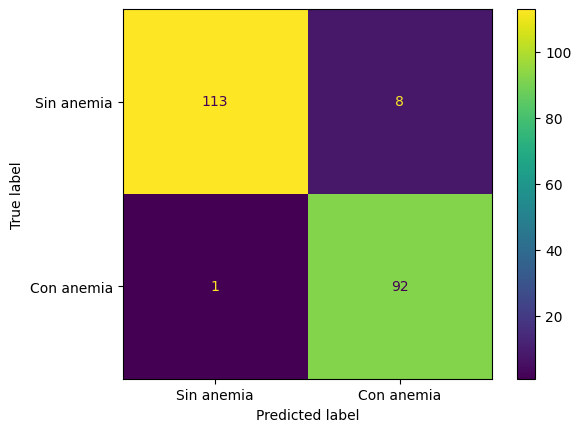

In [11]:
confusion_matrix_test = show_confusion_matrix(y_test, y_pred)
plt.show()

El modelo logro clasificar correctamente:

* 113 casos de pacientes sin anemia.
* 92 casos de pacientes con anemia.

---

## **Análisis**

La matriz de confusión evidencia que el modelo presenta un excelente desempeño clasificando ambas clases.

El modelo logro clasificar correctamente 205 de las 214 muestras del conjunto de prueba, cometiendo 9 errores en el proceso y obteniendo un resultado consistente con el `96%` obtenido en `accuracy`.

El modelo solo dejo de identificar 1 paciente con anemia, demostrando una elevada capacidad para detectar la clase positiva. Este resultado explica el `recall` obtenido en el análisis de métricas (`99%`).

Asimismo, el modelo produjo 8 falsos positivos(Pacientes que el modelo clasifico como positivos, cuando no tenian la enfermedad), indicando que la mayoría de los pacientes clasificados como anemicos realmente presentan la enfermedad. Este comportamiento es consistente con la `precision` obtenida(`92%`).

En conjunto, la distribución de errores observada en la matriz de confusión muestra que el modelo mantiene un buen equilibrio entre la detección de casos positivos y la correcta identificación de pacientes sin anemia, evidenciando un comportamiento sólido sobre el conjunto de prueba

# 8. Comparativa con el conjunto de validación

| Métrica   | Conjunto de Validación | Conjunto de Prueba | Diferencia (Prueba − Validación) |
| --------- | ---------------------: | -----------------: | -------------------------------: |
| Accuracy  |  0.96 |0.96 | 0.00 |
| Precision | 0.94 | 0.92 |-0.02 |
| Recall    | 0.98 |0.99 | +0.01 |
| F1-Score  | 0.96 |0.95 | -0.01 |


## **Análisis**

Se comparo el desempeño del modelo sobre el conjunto de validación y el conjunto de prueba con el objetivo de evaluar su capacidad de generalización. Los resultados obtenidos muestran métricas muy similares entre ambos conjuntos de datos:

* `accuracy` se mantuvo en `0.96`
* `precision` disminuyo de `0.94` a `0.92`
* `recall` aumento de `0.98` a `0.99`
* `F1-Score` disminuyo de `0.96` a `0.95`

Las diferencias observadas entre ambos conjuntos son pequeñas, indicando que el comportamiento del modelo es consistente cuando el modelo se enfrenta a datos no utilizados durante el entrenamiento.

Asimismo, la estabilidad en las métricas sugieren que el modelo logro capturar y aprender los patrones representativos del problema en lugar de depender de características específicas del conjunto de entrenamiento, evidenciando una adecuada capacidad de generalización.

El `recall` aumento de `0.98` a `0.99`, indicando que el modelo mantuvo (e incluso, mejoro ligeramente) su capacidad para identificar correctamente los casos positivos del conjunto de prueba. Este comportamiento resulta favorable dado que la detección de pacientes con anemia es el principal objetivo del proyecto.

Los resultados obtenidos sobre el conjunto de prueba son coherentes con los observados durante la validación. La similitud entre las métricas indica que el modelo presenta un desempeño estable y una buena capacidad de generalización.

# 9. Feature Importance

In [30]:
# importamos los nombres de las features

columns_names = np.load('/content/Anemia-Prediction-System/data/processed/feature_names.npy',
                        allow_pickle=True)
columns_names

array(['Gender', 'Hemoglobin', 'MCH', 'MCHC', 'MCV', 'Low_Hb',
       'HB_MCV_ratio', 'Score'], dtype=object)

In [31]:
feature_importances = pd.DataFrame(model.get_feature_importance(),
                                   index=columns_names,
                                   columns=['Importance'])

In [32]:
feature_importances.sort_values(ascending=False, by='Importance')

,Importance
Hemoglobin,85.999536
Gender,13.498942
Low_Hb,0.364823
Score,0.043718
HB_MCV_ratio,0.033983
MCV,0.028596
MCHC,0.023768
MCH,0.006634


# 10. SHAP Values

In [34]:
explainer = shap.TreeExplainer(model)

In [35]:
shap_values = explainer.shap_values(X_test)

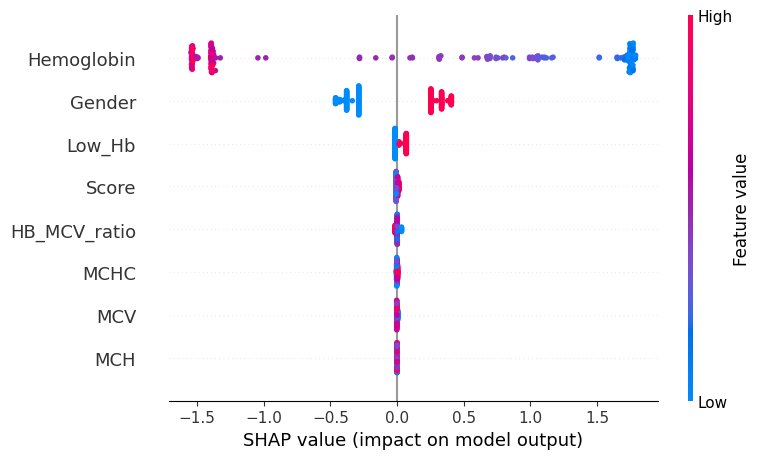

In [36]:
shap.summary_plot(
    shap_values,
    X_test,
    feature_names = columns_names
)

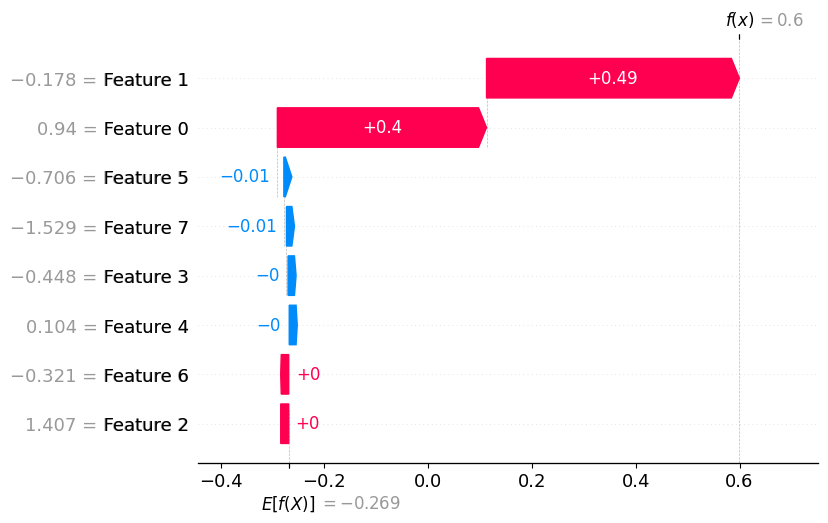

In [47]:
shap.plots.waterfall(
    explainer(X_test[[0]])[0]
)

# 11. Documentando los resultados